# Bangla Text Generation



In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import random
import urllib.request
import matplotlib.pyplot as plt
import os


torch.manual_seed(42)
np.random.seed(42)
random.seed(42)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'PyTorch {torch.__version__}')
print(f'Device : {device}')

PyTorch 2.10.0+cu128
Device : cuda


---
## Part 2: Bangla Text Generation with LSTM <a name="bangla"></a>

### Why LSTM for Bangla?

Bangla script has **complex character dependencies** — characters combine with vowel diacritics (মাত্রা), conjuncts (যুক্তাক্ষর), and have long-range grammatical patterns. The vanilla RNN struggles with these due to **vanishing gradients**. LSTMs solve this with memory cells:

```
           ┌─────────── Cell State (long-term memory) ───────────┐
           │                                                      │
input ──▶  [Forget Gate] → [Input Gate] → [Cell Update] → [Output Gate] ──▶ output
```

### Dataset: Rabindranath Tagore's Poems

We use poems by **Rabindranath Tagore**

The model will learn the character-level patterns of Tagore's Bangla and generate new text in his style.

---
### Step 2.1 — Download Bangla Text Dataset

In [2]:
bangla_text = """
আমার সোনার বাংলা, আমি তোমায় ভালোবাসি।
চিরদিন তোমার আকাশ, তোমার বাতাস, আমার প্রাণে বাজায় বাঁশি।
ও মা, ফাগুনে তোর আমের বনে ঘ্রাণে পাগল করে,
মরি হায়, হায় রে—
ও মা, অঘ্রানে তোর ভরা ক্ষেতে আমি কী দেখেছি মধুর হাসি।

আলো আমার আলো ওগো আলো ভুবন ভরা—
আলো নয়নের আলো হৃদয় হরা।
নাচে আলো নাচে ভাই আলোর নাচন,
পুষ্পদলে পুষ্পদলে তরঙ্গ লহরা।

যদি তোর ডাক শুনে কেউ না আসে তবে একলা চলো রে।
একলা চলো, একলা চলো, একলা চলো রে।
যদি কেউ কথা না কয়, ওরে ওরে ও অভাগা,
যদি সবাই থাকে মুখ ফিরায়ে সবাই করে ভয়—
তবে পরান খুলে
ও তুই মুখ ফুটে তোর মনের কথা একলা বলো রে।

আকাশ ভরা সূর্য তারা, বিশ্ব ভরা প্রাণ,
তাহারি মাঝখানে আমি পেয়েছি মোর স্থান,
বিস্ময়ে তাই জাগে আমার গান।
অন্ধকারের উৎস হতে উৎসারিত আলো—
সেই তো তোমার আলো।

মরিতে চাহি না আমি সুন্দর ভুবনে,
মানবের মাঝে আমি বাঁচিবার চাই।
সবার মাঝে মিশে যাই,
প্রতিদিন প্রভাতবেলা মধুর স্বপনে।

বাংলার মাটি বাংলার জল, বাংলার বায়ু বাংলার ফল—
পুণ্য হউক, পুণ্য হউক, পুণ্য হউক হে ভগবান।
বাংলার ঘর, বাংলার হাট, বাংলার বন, বাংলার মাঠ—
পূর্ণ হউক, পূর্ণ হউক, পূর্ণ হউক হে ভগবান।

আমার মাথা নত করে দাও হে তোমার চরণ-ধূলার তলে।
সকল অহংকার হে আমার ডুবাও চোখের জলে।
নিজেরে করিতে গৌরব দান, নিজেরে কেবলই করি অপমান,
আপনারে শুধু ঘেরিয়া ধরে মরি আপন মায়াজালে।

এসো হে বৈশাখ, এসো এসো।
তাপস-নিঃশ্বাস বায়ে মুমূর্ষুরে দাও উড়ায়ে,
বৎসরের আবর্জনা দূর হয়ে যাক—
যাক পুরাতন স্মৃতি যাক ভুলে যাওয়া গীতি,
অশ্রুবাষ্প সুদূরে মিলাক।

পুরানো সেই দিনের কথা ভুলবি কি রে হায়।
ও সেই চোখের দেখা, প্রাণের কথা, সে কি ভোলা যায়।
আয় আর একটিবার আয় রে সখা, প্রাণের মাঝে আয়।
মোরা সুখের দুখের কথা কব, প্রাণ জুড়াবে তায়।

আমি চিনি গো চিনি তোমারে, ওগো বিদেশিনী।
তুমি থাকো সিন্ধুপারে ওগো বিদেশিনী।
তোমার কথা জানি, তোমার গান গেয়েছি,
তোমার হাসির আলো পেয়েছি,
তোমার কাছে আমি চিরচেনা।

গগনে গগনে বাজে তব জয়ডঙ্কা হে।
পবনে পবনে ওঠে তব জয়শঙ্খ হে।
ঢেউয়ে ঢেউয়ে ফেনায় ফেনায়
তোমার চরণ পড়ে ধরণীর গায়—
মাটির বুকে লুটিয়ে পড়ি প্রণমি তোমায়।

আনন্দলোকে মঙ্গলালোকে বিরাজ সত্যসুন্দর।
মহিমা তব উদ্ভাসিত নিখিল জগত-মন্দির।
মহাবিশ্বে মহাকাশে মহাকালমাঝে,
সকলের মধ্যে জাগো, সকলের মাঝে।

যখন পড়বে না মোর পায়ের চিহ্ন এই বাটে,
আমি বাইব না মোর খেয়াতরী এই ঘাটে—
তখন কে বলে ভাই, কে বলে ভাই 'আমি নেই'
আমি তখন তোমার কাছে তোমার মাঝে।

সংকোচের বিহ্বলতা নিজেরে অপমান,
সংকটের কল্পনাতে হয়ো না ম্রিয়মান।
মুক্ত কর হে বন্ধন, মুক্ত করো হে দুঃখ—
তব কৃপার দীপ্তি হউক আমার পথের সাথি।

তোমায় গান শোনাব বলে তাইতো আমার আনাগোনা।
সারাদিন তোমার পথ চেয়ে থাকি, তুমি কি জানো না।
সকালবেলা তোমার নামে গাই আমার গান,
সন্ধ্যাবেলা তোমার কথা মনে করি, পাই শান্তি আর প্রাণ।

""" * 6  # repeat to build enough training data

bangla_text = bangla_text.strip()
print(f'\n Dataset size : {len(bangla_text):,} characters')
print(f'\n Sample text  :\n{bangla_text[:270]}')


 Dataset size : 14,457 characters

 Sample text  :
আমার সোনার বাংলা, আমি তোমায় ভালোবাসি।
চিরদিন তোমার আকাশ, তোমার বাতাস, আমার প্রাণে বাজায় বাঁশি।
ও মা, ফাগুনে তোর আমের বনে ঘ্রাণে পাগল করে,
মরি হায়, হায় রে—
ও মা, অঘ্রানে তোর ভরা ক্ষেতে আমি কী দেখেছি মধুর হাসি।

আলো আমার আলো ওগো আলো ভুবন ভরা—
আলো নয়নের আলো হৃদয় হরা।


### Step 2.2 — Preprocess Bangla Text

Bangla uses Unicode characters (U+0980–U+09FF). Each Bangla character, diacritic, and punctuation mark becomes a token — just like our music notes.

In [3]:
# Build Bangla vocabulary
b_chars    = sorted(set(bangla_text))
b_vocab    = len(b_chars)
b_char2idx = {c: i for i, c in enumerate(b_chars)}
b_idx2char = {i: c for c, i in b_char2idx.items()}

print(f'Bangla vocabulary size : {b_vocab} unique characters')

# Show which Unicode blocks are present
bangla_only = [c for c in b_chars if '\u0980' <= c <= '\u09ff']
print(f'   Bangla Unicode chars   : {len(bangla_only)}')
print(f'   Sample Bangla chars    : {" ".join(bangla_only[:20])}')

# Encode the full text
b_encoded = np.array([b_char2idx[c] for c in bangla_text], dtype=np.int64)

# Create training sequences
B_SEQ_LEN = 60
B_STEP    = 4

bX, bY = [], []
for i in range(0, len(b_encoded) - B_SEQ_LEN - 1, B_STEP):
    bX.append(b_encoded[i : i + B_SEQ_LEN])
    bY.append(b_encoded[i + 1 : i + B_SEQ_LEN + 1])

bX_tensor = torch.tensor(np.array(bX), dtype=torch.long)
bY_tensor = torch.tensor(np.array(bY), dtype=torch.long)

print(f'\n Training shapes — X: {bX_tensor.shape}, Y: {bY_tensor.shape}')
print(f'\n Example input  : {bangla_text[:B_SEQ_LEN]!r}')
print(f'   Example target : {bangla_text[1:B_SEQ_LEN+1]!r}')

Bangla vocabulary size : 60 unique characters
   Bangla Unicode chars   : 53
   Sample Bangla chars    : ঁ ং ঃ অ আ ই উ এ ও ক খ গ ঘ ঙ চ ছ জ ঝ ট ঠ

 Training shapes — X: torch.Size([3599, 60]), Y: torch.Size([3599, 60])

 Example input  : 'আমার সোনার বাংলা, আমি তোমায় ভালোবাসি।\nচিরদিন তোমার আকাশ, তো'
   Example target : 'মার সোনার বাংলা, আমি তোমায় ভালোবাসি।\nচিরদিন তোমার আকাশ, তোম'


### Step 2.3 — Build the LSTM Model


In [4]:
class BanglaLSTM(nn.Module):
    """
    Character-level LSTM for Bangla text generation.

    Key difference from MusicRNN:
      → Uses nn.LSTM which maintains both h (hidden) and c (cell) states
      → Cell state allows gradients to flow across long sequences (no vanishing)
      → Well-suited for Bangla's complex character dependencies

    Architecture:
        Embedding → Dropout → LSTM (2 layers) → Dropout → Linear
    """
    def __init__(self, vocab_size, embed_dim, hidden_dim, num_layers, dropout=0.35):
        super().__init__()
        self.hidden_dim = hidden_dim
        self.num_layers = num_layers


        # Complete the code here
        self.vocab_size = vocab_size
        self.embedding = nn.Embedding(vocab_size, embed_dim)

        self.lstm = nn.LSTM(
            input_size=embed_dim,
            hidden_size=hidden_dim,
            num_layers=num_layers,
            dropout=dropout if num_layers > 1 else 0,
            batch_first=True
        )

        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(hidden_dim, vocab_size)


    def forward(self, x, hidden=None):
        # complete the code here
        x = self.embedding(x)
        out, hidden = self.lstm(x, hidden)

        out = self.dropout(out)
        logits = self.fc(out)
        return logits, hidden

    def init_hidden(self, batch_size):
        # complete the code here
        h = torch.zeros(self.num_layers, batch_size, self.hidden_dim).to(device)
        c = torch.zeros(self.num_layers, batch_size, self.hidden_dim).to(device)

        return (h, c)


B_EMBED  = 128
B_HIDDEN = 512
B_LAYERS = 2

bangla_model = BanglaLSTM(b_vocab, B_EMBED, B_HIDDEN, B_LAYERS).to(device)

n_params = sum(p.numel() for p in bangla_model.parameters())
print(bangla_model)
print(f'\n Parameters: {n_params:,}')

BanglaLSTM(
  (embedding): Embedding(60, 128)
  (lstm): LSTM(128, 512, num_layers=2, batch_first=True, dropout=0.35)
  (dropout): Dropout(p=0.35, inplace=False)
  (fc): Linear(in_features=512, out_features=60, bias=True)
)

 Parameters: 3,454,524


### Step 2.4 — Train the LSTM

Training Bangla LSTM...

  Epoch   1/30  |  Loss: 3.2653
  Epoch   5/30  |  Loss: 0.1722
  Epoch  10/30  |  Loss: 0.1012
  Epoch  15/30  |  Loss: 0.0874
  Epoch  20/30  |  Loss: 0.0818
  Epoch  25/30  |  Loss: 0.0795
  Epoch  30/30  |  Loss: 0.0776

 Training complete!


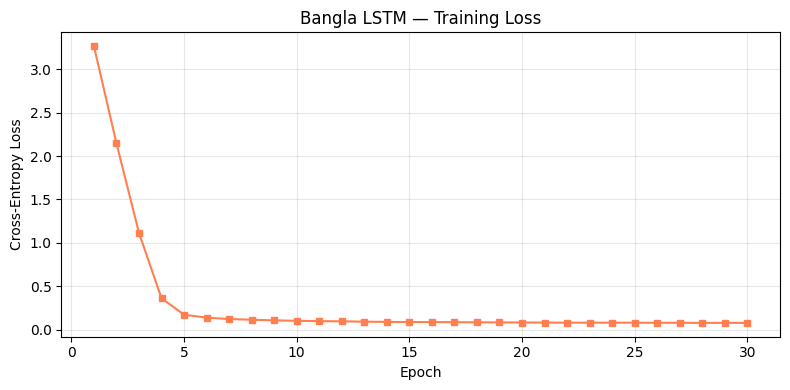

In [5]:
B_BATCH  = 128
B_EPOCHS = 30
B_LR     = 2e-3

b_criterion = nn.CrossEntropyLoss()
b_optimizer = optim.Adam(bangla_model.parameters(), lr=B_LR)
b_scheduler = optim.lr_scheduler.CosineAnnealingLR(b_optimizer, T_max=B_EPOCHS, eta_min=5e-5)

b_dataset = torch.utils.data.TensorDataset(bX_tensor, bY_tensor)
b_loader  = torch.utils.data.DataLoader(b_dataset, batch_size=B_BATCH, shuffle=True)

b_losses = []

print('Training Bangla LSTM...\n')
for epoch in range(1, B_EPOCHS + 1):
    # complete the code here
    bangla_model.train()
    total_loss = 0

    for x_batch, y_batch in b_loader:
        x_batch = x_batch.to(device)
        y_batch = y_batch.to(device)

        batch_size = x_batch.size(0)
        hidden = bangla_model.init_hidden(batch_size)

        # Detach hidden states (prevents backprop across batches)
        hidden = (hidden[0].detach(), hidden[1].detach())

        b_optimizer.zero_grad()

        logits, hidden = bangla_model(x_batch, hidden)

        # reshape for CrossEntropyLoss
        # (batch * seq_len, vocab_size) vs (batch * seq_len)
        logits = logits.reshape(-1, bangla_model.vocab_size)
        targets = y_batch.reshape(-1)

        loss = b_criterion(logits, targets)
        loss.backward()

        # gradient clipping (important for LSTM stability)
        torch.nn.utils.clip_grad_norm_(bangla_model.parameters(), 5)

        b_optimizer.step()

        total_loss += loss.item()

    avg = total_loss / len(b_loader)
    b_losses.append(avg)

    b_scheduler.step()

    if epoch % 5 == 0 or epoch == 1:
        print(f'  Epoch {epoch:>3}/{B_EPOCHS}  |  Loss: {avg:.4f}')

print('\n Training complete!')

# Plot training loss
plt.figure(figsize=(8, 4))
plt.plot(range(1, B_EPOCHS+1), b_losses, color='coral', marker='s', ms=4)
plt.title('Bangla LSTM — Training Loss')
plt.xlabel('Epoch'); plt.ylabel('Cross-Entropy Loss')
plt.grid(True, alpha=0.3); plt.tight_layout(); plt.show()

### Step 2.5 — Generate Bangla Text

Now we feed the LSTM a Bangla seed phrase and let it write poetry in the style of Tagore!

In [6]:
def generate_bangla(model, seed_text, gen_length=300, temperature=0.8):
    """
    Generate Bangla text autoregressively.

    Args:
        model       : trained BanglaLSTM
        seed_text   : starting Bangla string
        gen_length  : characters to generate
        temperature : sampling temperature
    Returns:
        str: seed + generated text
    """
    model.eval()
    generated = seed_text
    input_seq = torch.tensor(
        [b_char2idx[c] for c in seed_text],
        dtype=torch.long
    ).unsqueeze(0).to(device)

    # complete the code here
    hidden = model.init_hidden(1)

    with torch.no_grad():
        # Feed the seed text first
        for i in range(len(seed_text) - 1):
            _, hidden = model(input_seq[:, i:i+1], hidden)

        last_char = input_seq[:, -1:]  # last char of seed

        for _ in range(gen_length):
            logits, hidden = model(last_char, hidden)

            logits = logits[:, -1, :] / temperature  # apply temperature
            probs = torch.softmax(logits, dim=-1)

            # sample next character
            next_idx = torch.multinomial(probs, num_samples=1).item()

            next_char = b_idx2char[next_idx]
            generated += next_char

            # feed back into model
            last_char = torch.tensor([[next_idx]], dtype=torch.long).to(device)


    return generated



seeds = [
    'আমার',
    'আলো',
    'বাঁশি'
]

print('Generated Bangla Text (Tagore-style)\n' + '═'*55)

for seed in seeds:
    for temp in [0.9, 1.2, 1.9]:
        result = generate_bangla(bangla_model, seed, gen_length=100, temperature=temp)
        print(f'\n Seed: "{seed}"  |  Temperature: {temp}')
        print('─'*50)
        print(result)
    print()

Generated Bangla Text (Tagore-style)
═══════════════════════════════════════════════════════

 Seed: "আমার"  |  Temperature: 0.9
──────────────────────────────────────────────────
আমার আলো ওগো আলো ভুবন ভরা—
আলো নয়নের আলো হৃদয় হরা।
নাচে আলো নাচে ভাই আলোর নাচন,
পুষ্পদলে পুষ্পদলে তরঙ্

 Seed: "আমার"  |  Temperature: 1.2
──────────────────────────────────────────────────
আমার পথের সাথি।

তোমায় গান শোনাব বলেে তাইতো আমার আনাগোনা।
সারাদিন তোমার পথ চেয়ে থাকি, তুমি কি জানো না।

 Seed: "আমার"  |  Temperature: 1.9
──────────────────────────────────────────────────
আমার আনাগোনা।
সারাদিন তোমার ণথা চূরি র আপমেয় গেয়েছি,
তোমার হাসির আলো পেয়েছি,
তোমার কাছে আমি চিরচেনা।



 Seed: "আলো"  |  Temperature: 0.9
──────────────────────────────────────────────────
আলো হৃদয় হরা।
নাচে আলো নাচে ভাই আলোর নাচন,
পুষ্পদলে পুষ্পদলে তরঙ্গ লহরা।

যদি তোর ডাক শুনে কেউ না আসে 

 Seed: "আলো"  |  Temperature: 1.2
──────────────────────────────────────────────────
আলো—
সেই তো তোমার আলো।

মরিতে চাহি না আমি সুন্দর ভুবনে